# Block 11: Notebook Analysis

This notebook analyses the completed GDELT Southeast Asia signal pipeline using the analysis marts created in dbt.

## Purpose

The notebook supports two use cases:

1. Regional spike monitoring  
2. Country event and actor profile analysis  

Important framing: GDELT is treated as a media-coded event signal source, not as a verified ground-truth incident database.

In [1]:
from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB_PATH = PROJECT_ROOT / "db" / "gdelt_sea.duckdb"
OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

con = duckdb.connect(str(DB_PATH))

print(f"Connected to: {DB_PATH}")

Connected to: /home/kennywong/code/ntu-sctp/repos/rci-gdelt-sea-signal-pipeline/db/gdelt_sea.duckdb


## 1. Confirm available marts

In [2]:
tables_df = con.execute("""
    SELECT
        table_schema,
        table_name,
        table_type
    FROM information_schema.tables
    WHERE table_schema = 'marts'
    ORDER BY table_name
""").fetchdf()

tables_df

,table_schema,table_name,table_type
0,marts,dim_actor,BASE TABLE
1,marts,dim_country,BASE TABLE
2,marts,dim_date,BASE TABLE
3,marts,dim_event_code,BASE TABLE
4,marts,fact_event_signal,BASE TABLE
5,marts,mart_country_actor_profile,BASE TABLE
6,marts,mart_country_event_profile,BASE TABLE
7,marts,mart_regional_spike_monitoring,BASE TABLE


## 2. Use Case 1: Regional spike monitoring

This view checks weekly event-signal volume by country and flags possible spikes using simple week-on-week logic.

Because the current project uses a controlled sample of downloaded GDELT files, the values should be treated as demonstration outputs, not final operational intelligence.

In [3]:
regional_spike_df = con.execute("""
    SELECT
        country_name,
        week_start_date,
        event_signal_count,
        previous_week_event_signal_count,
        week_on_week_change,
        week_on_week_ratio,
        conflict_signal_count,
        public_safety_signal_count,
        total_mentions,
        total_sources,
        total_articles,
        avg_tone,
        spike_flag
    FROM marts.mart_regional_spike_monitoring
    ORDER BY week_start_date DESC, event_signal_count DESC
""").fetchdf()

regional_spike_df

,country_name,week_start_date,event_signal_count,previous_week_event_signal_count,week_on_week_change,week_on_week_ratio,conflict_signal_count,public_safety_signal_count,total_mentions,total_sources,total_articles,avg_tone,spike_flag
0,Philippines,2026-05-18,131,2,129,65.5,37.0,22.0,653.0,131.0,648.0,-3.116556,Possible spike
1,Malaysia,2026-05-18,116,<NA>,116,NaN,28.0,14.0,673.0,117.0,645.0,-1.892174,No prior week
2,Vietnam,2026-05-18,56,<NA>,56,NaN,10.0,3.0,242.0,56.0,238.0,1.281330,No prior week
3,Indonesia,2026-05-18,48,1,47,48.0,19.0,5.0,322.0,54.0,322.0,-1.662259,Possible spike
4,Singapore,2026-05-18,47,<NA>,47,NaN,11.0,0.0,266.0,48.0,266.0,1.223329,No prior week
5,Thailand,2026-05-18,27,<NA>,27,NaN,4.0,2.0,130.0,27.0,130.0,2.964138,No prior week
6,Myanmar,2026-05-18,21,<NA>,21,NaN,3.0,3.0,90.0,21.0,90.0,0.826042,No prior week
7,Cambodia,2026-05-18,5,<NA>,5,NaN,2.0,0.0,18.0,5.0,18.0,-5.565217,No prior week
8,Laos,2026-05-18,3,<NA>,3,NaN,1.0,1.0,12.0,3.0,12.0,-5.387822,No prior week
9,Philippines,2026-05-11,2,<NA>,2,NaN,2.0,2.0,8.0,2.0,8.0,-7.385230,No prior week


In [4]:
regional_spike_df.to_csv(
    OUTPUT_TABLES_DIR / "regional_spike_monitoring.csv",
    index=False
)

print("Saved regional spike table.")

Saved regional spike table.


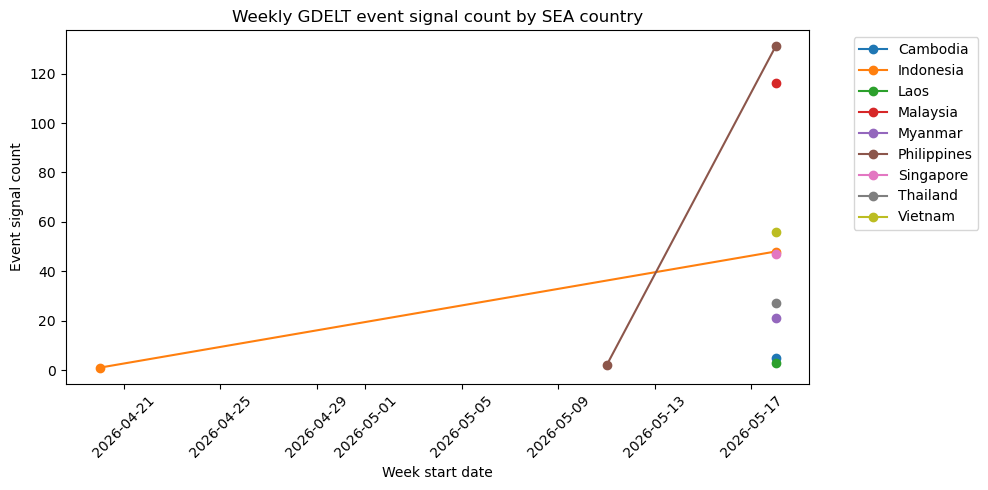

Saved figure to: /home/kennywong/code/ntu-sctp/repos/rci-gdelt-sea-signal-pipeline/outputs/figures/weekly_event_signal_count_by_country.png


In [5]:
plot_df = regional_spike_df.sort_values(["week_start_date", "country_name"])

plt.figure(figsize=(10, 5))
for country, group in plot_df.groupby("country_name"):
    plt.plot(group["week_start_date"], group["event_signal_count"], marker="o", label=country)

plt.title("Weekly GDELT event signal count by SEA country")
plt.xlabel("Week start date")
plt.ylabel("Event signal count")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

figure_path = OUTPUT_FIGURES_DIR / "weekly_event_signal_count_by_country.png"
plt.savefig(figure_path, dpi=150)
plt.show()

print(f"Saved figure to: {figure_path}")

## 3. Use Case 2A: Country event profile

This view identifies dominant event codes and event classes by country.

In [6]:
event_profile_df = con.execute("""
    SELECT
        country_name,
        event_code_key,
        event_root_code,
        quad_class_label,
        is_conflict_quad,
        is_public_safety_signal,
        event_signal_count,
        share_of_country_events,
        country_event_rank,
        total_mentions,
        total_sources,
        total_articles,
        avg_tone
    FROM marts.mart_country_event_profile
    WHERE country_event_rank <= 10
    ORDER BY country_name, country_event_rank
""").fetchdf()

event_profile_df

,country_name,event_code_key,event_root_code,quad_class_label,is_conflict_quad,is_public_safety_signal,event_signal_count,share_of_country_events,country_event_rank,total_mentions,total_sources,total_articles,avg_tone
0,Cambodia,010,01,Verbal Cooperation,False,False,2,0.4000,1,4.0,2.0,4.0,-8.043478
1,Cambodia,111,11,Verbal Conflict,True,False,2,0.4000,2,4.0,2.0,4.0,-8.043478
2,Cambodia,046,04,Verbal Cooperation,False,False,1,0.2000,3,10.0,1.0,10.0,4.347826
3,Indonesia,071,07,Material Cooperation,False,False,5,0.1020,1,30.0,5.0,30.0,-0.086513
4,Indonesia,111,11,Verbal Conflict,True,False,5,0.1020,2,30.0,5.0,30.0,-4.460955
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,Vietnam,100,10,Verbal Conflict,True,False,4,0.0714,6,10.0,4.0,10.0,-0.058401
70,Vietnam,013,01,Verbal Cooperation,False,False,3,0.0536,7,10.0,3.0,10.0,5.617978
71,Vietnam,061,06,Material Cooperation,False,False,3,0.0536,8,15.0,3.0,15.0,-1.128668
72,Vietnam,020,02,Verbal Cooperation,False,False,2,0.0357,9,14.0,2.0,14.0,0.862157


In [7]:
event_profile_df.to_csv(
    OUTPUT_TABLES_DIR / "country_event_profile_top10.csv",
    index=False
)

print("Saved country event profile table.")

Saved country event profile table.


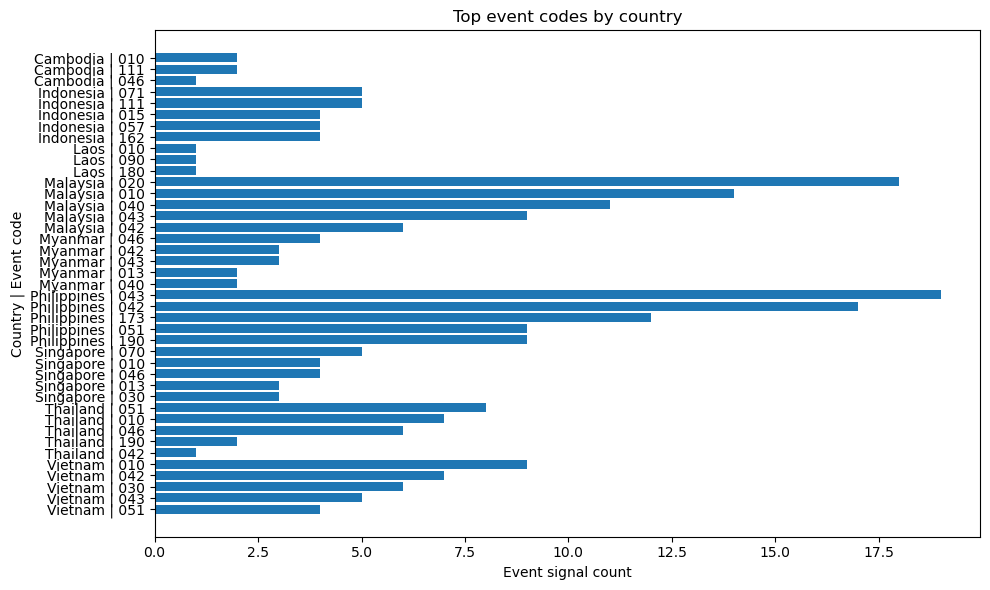

Saved figure to: /home/kennywong/code/ntu-sctp/repos/rci-gdelt-sea-signal-pipeline/outputs/figures/top_event_codes_by_country.png


In [8]:
top_event_df = event_profile_df[event_profile_df["country_event_rank"] <= 5].copy()
top_event_df["country_event_label"] = (
    top_event_df["country_name"]
    + " | "
    + top_event_df["event_code_key"].astype(str)
)

plt.figure(figsize=(10, 6))
plt.barh(top_event_df["country_event_label"], top_event_df["event_signal_count"])
plt.title("Top event codes by country")
plt.xlabel("Event signal count")
plt.ylabel("Country | Event code")
plt.gca().invert_yaxis()
plt.tight_layout()

figure_path = OUTPUT_FIGURES_DIR / "top_event_codes_by_country.png"
plt.savefig(figure_path, dpi=150)
plt.show()

print(f"Saved figure to: {figure_path}")

## 4. Use Case 2B: Country actor profile

This view identifies actors that frequently appear in each country’s media-coded event signals.

Actor labels are generated by GDELT and can be noisy. They should be used as directional signals, not clean verified entity records.

In [9]:
actor_profile_df = con.execute("""
    SELECT
        country_name,
        actor_position,
        COALESCE(actor_name, actor_code, actor_country_code, 'Unknown') AS actor_label,
        actor_code,
        actor_country_code,
        actor_type1_code,
        actor_event_signal_count,
        conflict_signal_count,
        public_safety_signal_count,
        country_actor_rank,
        total_mentions,
        total_sources,
        total_articles,
        avg_tone
    FROM marts.mart_country_actor_profile
    WHERE country_actor_rank <= 10
    ORDER BY country_name, country_actor_rank
""").fetchdf()

actor_profile_df

,country_name,actor_position,actor_label,actor_code,actor_country_code,actor_type1_code,actor_event_signal_count,conflict_signal_count,public_safety_signal_count,country_actor_rank,total_mentions,total_sources,total_articles,avg_tone
0,Cambodia,Actor 1,CAMBODIA,KHM,KHM,None,4,2.0,0.0,1,8.0,4.0,8.0,-8.043478
1,Cambodia,Actor 2,POLICE OFFICER,COP,None,COP,4,2.0,0.0,2,8.0,4.0,8.0,-8.043478
2,Cambodia,Actor 2,AUSTRALIA,AUS,AUS,None,1,0.0,0.0,3,10.0,1.0,10.0,4.347826
3,Cambodia,Actor 1,AUSTRALIA,AUSGOV,AUS,GOV,1,0.0,0.0,4,10.0,1.0,10.0,4.347826
4,Indonesia,Actor 2,GOVERNMENT,GOV,None,GOV,6,1.0,0.0,1,39.0,8.0,39.0,-3.464100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,Vietnam,Actor 2,ACTIVIST,OPP,None,OPP,2,2.0,2.0,6,8.0,2.0,8.0,-0.607903
73,Vietnam,Actor 1,CHIEF EXECUTIVE,GOV,None,GOV,2,0.0,0.0,7,8.0,2.0,8.0,5.617978
74,Vietnam,Actor 1,CIVILIAN,CVL,None,CVL,2,0.0,0.0,8,2.0,2.0,2.0,-0.607903
75,Vietnam,Actor 2,CORPORATION,BUS,None,BUS,2,0.0,0.0,9,8.0,2.0,8.0,5.617978


In [10]:
actor_profile_df.to_csv(
    OUTPUT_TABLES_DIR / "country_actor_profile_top10.csv",
    index=False
)

print("Saved country actor profile table.")

Saved country actor profile table.


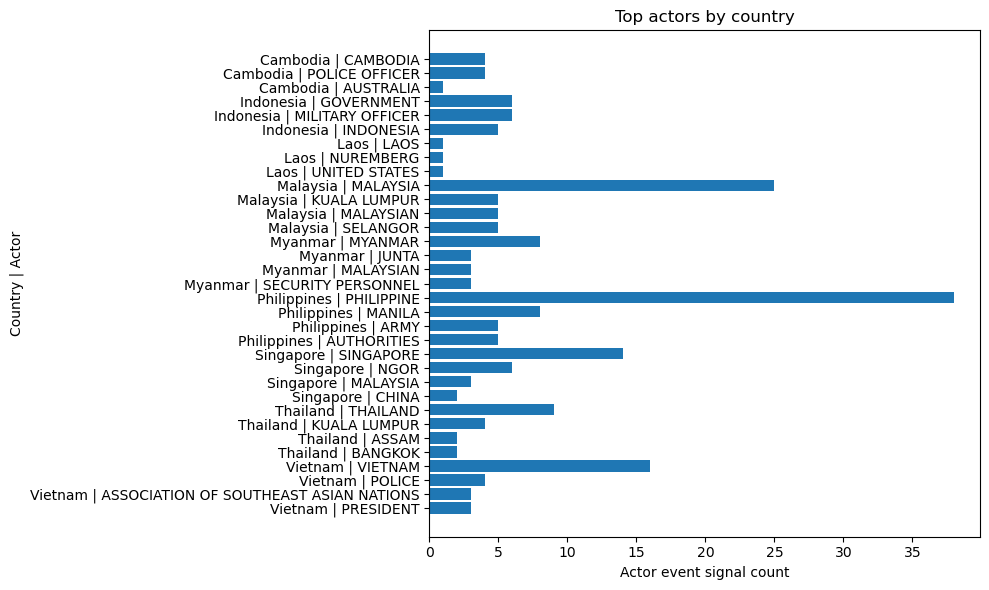

Saved figure to: /home/kennywong/code/ntu-sctp/repos/rci-gdelt-sea-signal-pipeline/outputs/figures/top_actors_by_country.png


In [11]:
top_actor_df = actor_profile_df[actor_profile_df["country_actor_rank"] <= 5].copy()
top_actor_df["country_actor_label"] = (
    top_actor_df["country_name"]
    + " | "
    + top_actor_df["actor_label"].astype(str)
)

plt.figure(figsize=(10, 6))
plt.barh(top_actor_df["country_actor_label"], top_actor_df["actor_event_signal_count"])
plt.title("Top actors by country")
plt.xlabel("Actor event signal count")
plt.ylabel("Country | Actor")
plt.gca().invert_yaxis()
plt.tight_layout()

figure_path = OUTPUT_FIGURES_DIR / "top_actors_by_country.png"
plt.savefig(figure_path, dpi=150)
plt.show()

print(f"Saved figure to: {figure_path}")

## 5. Summary observations

Use this section to write final project observations after reviewing the tables and charts.

Suggested framing:

- Which countries show the highest event signal volume?
- Which countries have possible spike flags?
- Which event classes dominate the sample?
- Which actors appear frequently?
- What are the limitations of using a controlled sample?
- How should public-safety stakeholders interpret these outputs?

In [12]:
summary_df = con.execute("""
    SELECT
        'event_rows' AS metric,
        COUNT(*) AS value
    FROM marts.fact_event_signal

    UNION ALL

    SELECT
        'countries_in_fact',
        COUNT(DISTINCT country_key)
    FROM marts.fact_event_signal

    UNION ALL

    SELECT
        'event_codes_in_fact',
        COUNT(DISTINCT event_code_key)
    FROM marts.fact_event_signal

    UNION ALL

    SELECT
        'actors_in_dim_actor',
        COUNT(*)
    FROM marts.dim_actor
""").fetchdf()

summary_df.to_csv(
    OUTPUT_TABLES_DIR / "analysis_summary_metrics.csv",
    index=False
)

summary_df

,metric,value
0,event_rows,457
1,countries_in_fact,9
2,event_codes_in_fact,56
3,actors_in_dim_actor,176


In [13]:
con.close()
print("Notebook analysis complete.")

Notebook analysis complete.
